Integrantes: Guillermo Hernández, Juan Acuña, Emmanuel Wilchez

## 0. LIBRERIAS

In [ ]:
!pip install timm --quiet

In [ ]:
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset, random_split
from torchvision import transforms
from torchvision.datasets import GTSRB
import timm
from collections import defaultdict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import torch.cuda.amp as amp

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

Dispositivo: cuda


## 1. Descarga GTSRB

In [ ]:
raw_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
train_raw = GTSRB(root='./data', split='train', download=True, transform=raw_transform)
print(f'Imágenes descargadas: {len(train_raw)}')

Imágenes descargadas: 26640


## 2. Balanceo (máx. 250 imágenes por clase)

In [ ]:
MAX_PER_CLASS = 250; NUM_CLASSES = 43
class_indices = defaultdict(list)
for idx, (_, label) in enumerate(train_raw):
    class_indices[label].append(idx)

balanced_indices = []
for cls in range(NUM_CLASSES):
    indices = class_indices[cls]; random.shuffle(indices)
    balanced_indices.extend(indices[:MAX_PER_CLASS])
random.shuffle(balanced_indices)

balanced_dataset = Subset(train_raw, balanced_indices)
print(f'Total imágenes balanceadas: {len(balanced_indices)}')

Total imágenes balanceadas: 9960


## 3. Media y std del dataset balanceado

In [ ]:
loader_stats = DataLoader(balanced_dataset, batch_size=256, shuffle=False, num_workers=2)
mean = torch.zeros(3); std = torch.zeros(3); total = 0
for imgs, _ in loader_stats:
    b = imgs.size(0); imgs = imgs.view(b, 3, -1)
    mean += imgs.mean(2).sum(0); std += imgs.std(2).sum(0); total += b
mean /= total; std /= total
print(f'Media: {mean}\nStd:   {std}')

Media: tensor([0.3398, 0.3144, 0.3255])
Std:   tensor([0.1662, 0.1655, 0.1744])


## 4. Transformaciones y división 70/15/15

> Agregar bloque entrecomillado



In [ ]:
n = len(balanced_indices)
n_train = int(0.70 * n); n_val = int(0.15 * n); n_test = n - n_train - n_val
gen = torch.Generator().manual_seed(SEED)
train_sub, val_sub, test_sub = random_split(balanced_dataset, [n_train, n_val, n_test], generator=gen)

BATCH = 32
train_loader = DataLoader(TransformSubset(train_sub, train_transform),    batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(TransformSubset(val_sub,   val_test_transform), batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(TransformSubset(test_sub,  val_test_transform), batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')

Train: 6972 | Val: 1494 | Test: 1494


## 5. Construcción del modelo Swin-Transformer

In [ ]:
class SwinGTSRB(nn.Module):
    """
    Envuelve el backbone Swin-Tiny de timm (con num_classes=0, que ya devuelve
    [B, 768] tras su propio global-avg-pool) y le añade una cabeza clasificadora.
    Así no interferimos con el pipeline interno de timm.
    """
    def __init__(self, num_classes=43, dropout=0.4):
        super().__init__()
        # backbone devuelve tensor 2D [B, 768] directamente
        self.features = timm.create_model(
            'swin_tiny_patch4_window7_224', pretrained=True, num_classes=0
        )
        in_f = self.features.num_features   # 768
        self.head = nn.Sequential(
            nn.Linear(in_f, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(1024, 512),  nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)   # [B, 768] — timm ya hizo el pooling
        return self.head(x)    # [B, 43]


model = SwinGTSRB(num_classes=43).to(DEVICE)
print(f'Modelo listo. Parámetros totales: {sum(p.numel() for p in model.parameters()):,}')

Modelo listo. Parámetros totales: 28,856,741


## 6. Funciones auxiliares de entrenamiento

In [ ]:
def freeze_backbone(model):
    # ahora el backbone está en model.features, la cabeza en model.head
    for name, p in model.named_parameters():
        p.requires_grad = name.startswith('head')

def unfreeze_backbone(model):
    for p in model.parameters():
        p.requires_grad = True

def run_epoch(model, loader, criterion, optimizer=None, train=True, scaler=None):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    autocast_ctx = (torch.amp.autocast('cuda') if DEVICE.type == 'cuda'
                    else torch.amp.autocast('cpu'))
    with torch.set_grad_enabled(train):
        for imgs, labels in tqdm.tqdm(loader, desc='Train' if train else 'Val', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            with autocast_ctx:
                out  = model(imgs)
                loss = criterion(out, labels)
            if train:
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

## 7. Entrenamiento – Fase 1 (cabeza, 10 épocas)

In [ ]:
criterion = nn.CrossEntropyLoss()
history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

freeze_backbone(model)
opt1    = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=1e-3, weight_decay=1e-4)
scaler1 = torch.amp.GradScaler('cuda')

for ep in tqdm.tqdm(range(1, 11), desc='Phase 1'):
    tl, ta = run_epoch(model, train_loader, criterion, opt1, train=True, scaler=scaler1)
    vl, va = run_epoch(model, val_loader,   criterion, train=False)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    print(f'Fase1 Ep {ep:02d}/10 | Loss {tl:.4f}/{vl:.4f} | Acc {ta:.4f}/{va:.4f}')

## 8. Entrenamiento – Fase 2 (fine-tuning completo, 20 épocas)

In [ ]:
unfreeze_backbone(model)
backbone_params = [p for n, p in model.named_parameters() if not n.startswith('head')]
opt2 = optim.AdamW([
    {'params': backbone_params,         'lr': 1e-5},
    {'params': model.head.parameters(), 'lr': 1e-4}
], weight_decay=1e-4)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt2, mode='max', factor=0.5, patience=3)
scaler2 = amp.GradScaler()

best_val, best_state, no_improve = 0.0, None, 0
for ep in tqdm.tqdm(range(1, 21), desc='Phase 2'):
    tl, ta = run_epoch(model, train_loader, criterion, opt2, train=True, scaler=scaler2)
    vl, va = run_epoch(model, val_loader,   criterion, train=False)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    sched.step(va)
    if va > best_val:
        best_val = va
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}; no_improve = 0
    else:
        no_improve += 1
    print(f'Fase2 Ep {ep:02d}/20 | Loss {tl:.4f}/{vl:.4f} | Acc {ta:.4f}/{va:.4f} | Best {best_val:.4f}')
    if no_improve >= 6: print(f'Early stopping en época {ep}'); break

model.load_state_dict(best_state)
torch.save(model.state_dict(), 'swin_transformer_gtsrb.pth')
np.save('history_swin.npy', history)
print(f'\nMejor val accuracy: {best_val:.4f}')

/tmp/ipykernel_3655/48446936.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler2 = amp.GradScaler()
Train: 100%|██████████| 218/218 [00:50<00:00,  5.07it/s]
                                                        
Phase 2:   5%|▌         | 1/20 [00:55<17:36, 55.62s/it]

Fase2 Ep 01/20 | Loss 0.2378/0.1126 | Acc 0.9192/0.9672 | Best 0.9672



Train: 100%|██████████| 218/218 [00:51<00:00,  4.42it/s]
                                                        
Phase 2:  10%|█         | 2/20 [01:50<16:37, 55.41s/it]

Fase2 Ep 02/20 | Loss 0.1358/0.0879 | Acc 0.9561/0.9732 | Best 0.9732



Train: 100%|██████████| 218/218 [00:50<00:00,  4.89it/s]
                                                        
Phase 2:  15%|█▌        | 3/20 [02:45<15:36, 55.10s/it]

...

Fase2 Ep 18/20 | Loss 0.0150/0.0193 | Acc 0.9963/0.9946 | Best 0.9946



Train: 100%|██████████| 218/218 [00:54<00:00,  4.72it/s]
                                                        
Phase 2:  95%|█████████▌| 19/20 [17:39<00:57, 57.14s/it]

Fase2 Ep 19/20 | Loss 0.0130/0.0193 | Acc 0.9964/0.9933 | Best 0.9946



Train: 100%|██████████| 218/218 [00:53<00:00,  4.90it/s]
                                                        
Phase 2: 100%|██████████| 20/20 [18:36<00:00, 55.81s/it]


Fase2 Ep 20/20 | Loss 0.0105/0.0203 | Acc 0.9977/0.9926 | Best 0.9946

Mejor val accuracy: 0.9946


## 9. Curvas de entrenamiento

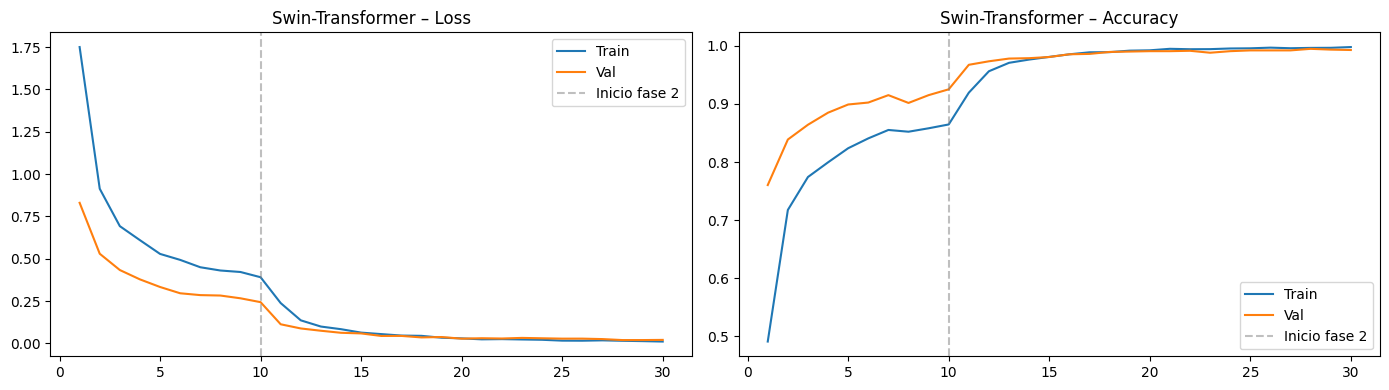

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
eps = range(1, len(history['train_loss']) + 1)
ax1.plot(eps, history['train_loss'], label='Train'); ax1.plot(eps, history['val_loss'], label='Val')
ax1.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='Inicio fase 2')
ax1.set_title('Swin-Transformer – Loss'); ax1.legend()
ax2.plot(eps, history['train_acc'],  label='Train'); ax2.plot(eps, history['val_acc'],  label='Val')
ax2.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='Inicio fase 2')
ax2.set_title('Swin-Transformer – Accuracy'); ax2.legend()
plt.tight_layout(); plt.savefig('swin_curves.png', dpi=120); plt.show()

## 10. Evaluación en test set

Evaluating: 100%|██████████| 47/47 [00:07<00:00,  6.37it/s]


Test Accuracy Swin-Transformer: 0.9920
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       0.97      0.94      0.96        36
           2       0.95      1.00      0.98        41
           3       1.00      0.97      0.99        35
           4       0.97      0.95      0.96        37
           5       0.98      1.00      0.99        49
           6       1.00      1.00      1.00        48
           7       0.94      0.97      0.95        30
           8       1.00      0.98      0.99        42
           9       1.00      1.00      1.00        33
          10       1.00      1.00      1.00        31
          11       1.00      0.97      0.99        34
          12       1.00      1.00      1.00        42
          13       1.00      1.00      1.00        40
          14       1.00      0.97      0.98        32
          15       1.00      1.00      1.00        43
          16       1.00      1.00      1.0

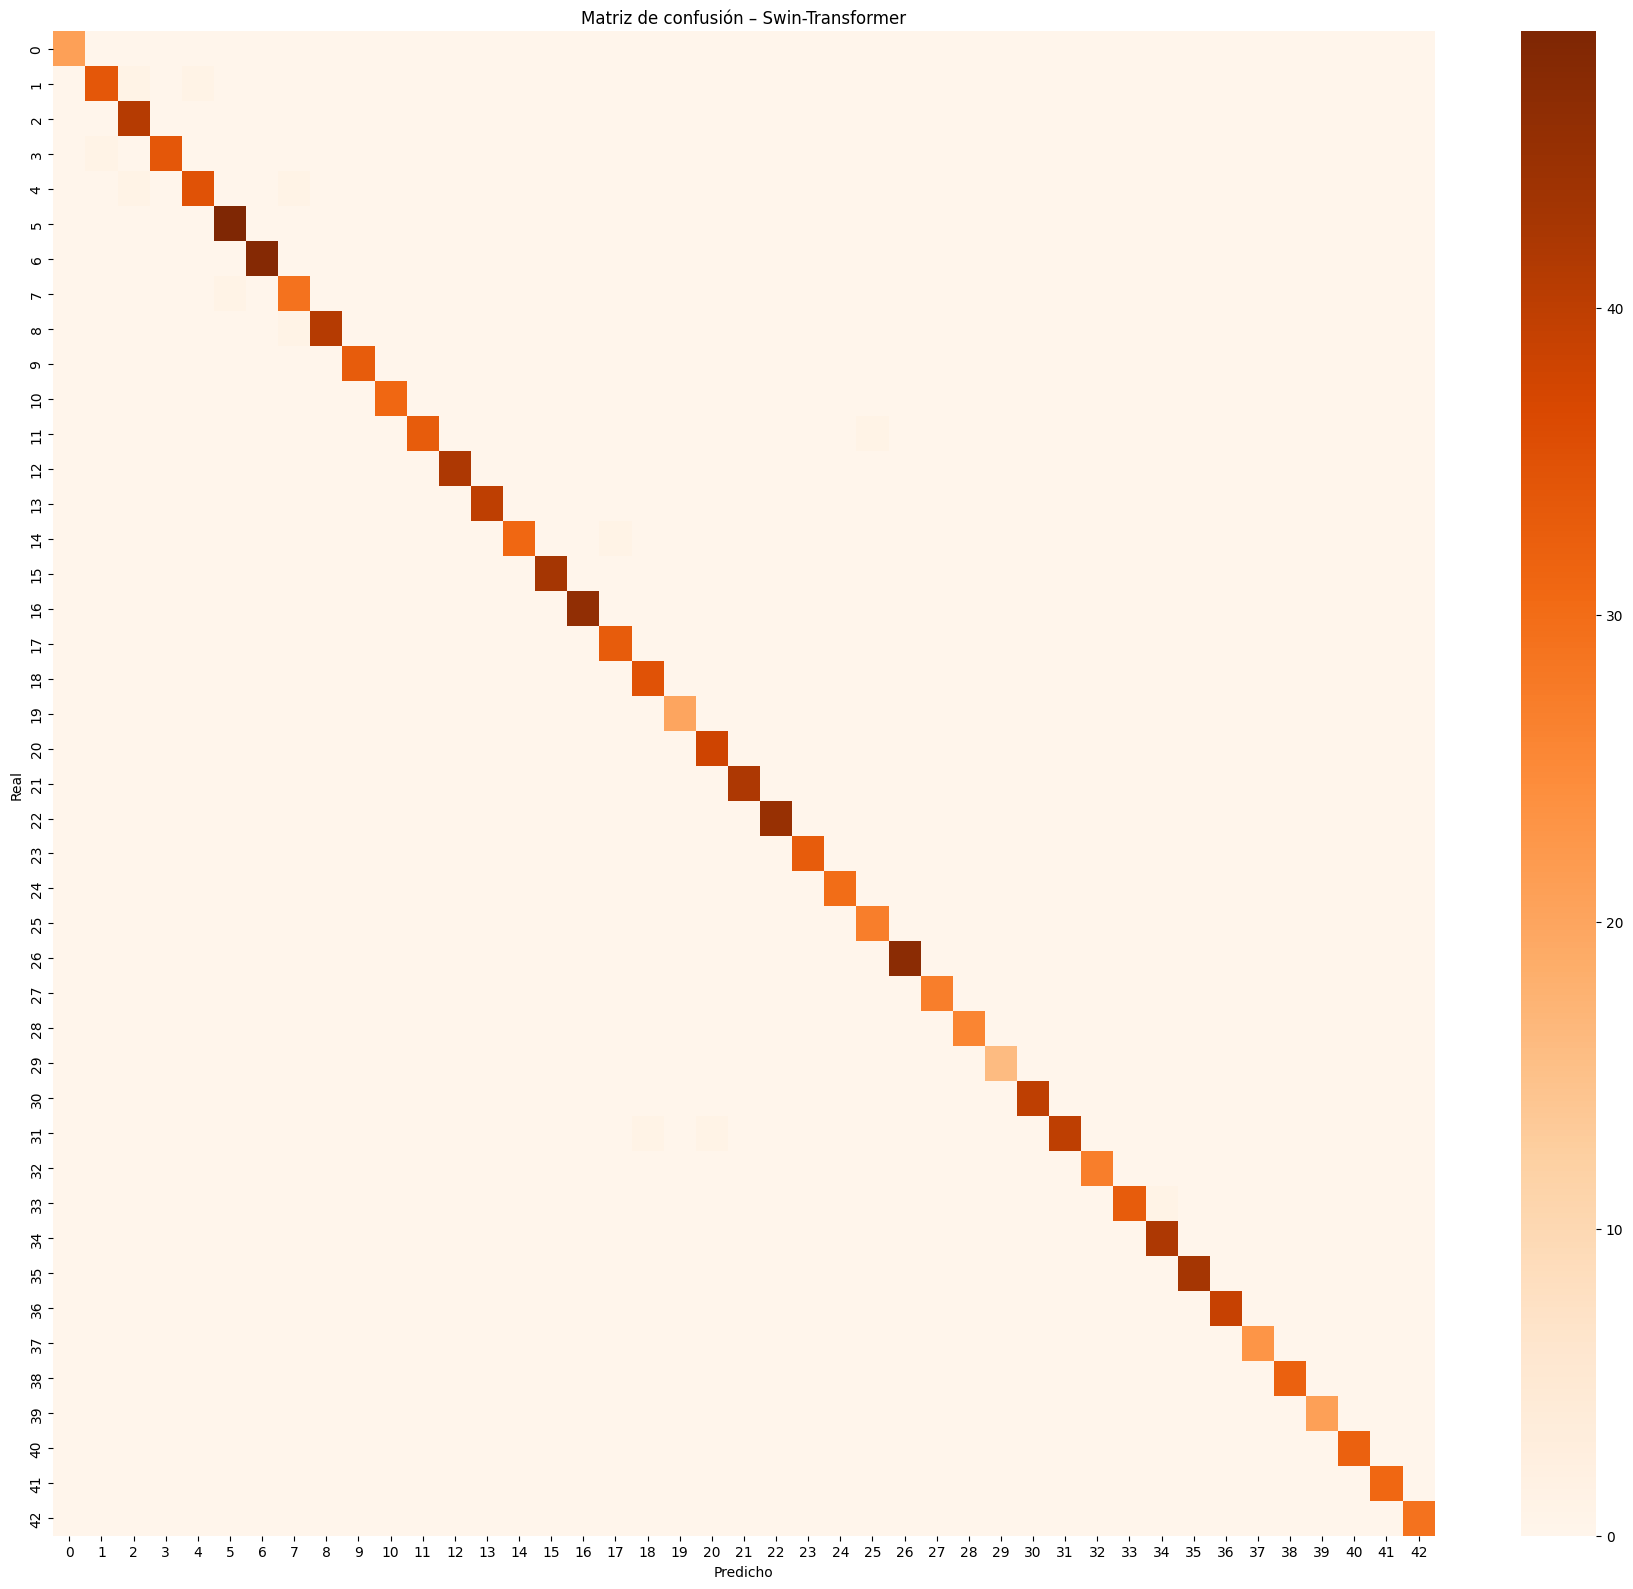

Predicciones guardadas en preds_swin.npy


In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm.tqdm(test_loader, desc='Evaluating'):
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy()); all_labels.extend(labels.numpy())

acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f'Test Accuracy Swin-Transformer: {acc:.4f}')
print(classification_report(all_labels, all_preds, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, annot=False, cmap='Oranges', ax=ax)
ax.set_title('Matriz de confusión – Swin-Transformer')
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.tight_layout(); plt.savefig('swin_confusion.png', dpi=120); plt.show()

np.save('preds_swin.npy',  np.array(all_preds))
np.save('labels_test.npy', np.array(all_labels))
print('Predicciones guardadas en preds_swin.npy')